# Online Evaluation Results

In [1]:
import csv
import os

import numpy as np
import matplotlib.pyplot as plt

from plot_utils import set_plot_style, set_legend_style

RESULTS_DIR = 'results/online'
EXTINCTIONS = 80, 200, 1000
CAMERAS = 'front', 'turntable'

In [2]:
set_plot_style()

In [3]:
results = {}
for subdir in os.listdir(RESULTS_DIR):
    subdir_path = os.path.join(RESULTS_DIR, subdir)
    if not os.path.isdir(subdir_path):
        continue
    results[subdir] = {}
    for filename in os.listdir(subdir_path):
        if not filename.endswith('.csv'):
            continue
        volume, extinction, transfer_function = filename[:-4].rsplit('_', 2)
        with open(os.path.join(subdir_path, filename), 'r') as f:
            reader = csv.DictReader(f)
            data = [{k: float(v) for k, v in row.items()} for row in reader]
            results[subdir][(volume, int(extinction), int(transfer_function))] = data

In [4]:
def plot_loss(ax, results, camera, experiment, smoothing_window=5, c=None, ls='-'):
    data = results[camera]
    times = [d['time_ms'] / 1000 for d in data[experiment]]
    values = [d['val_loss'] for d in data[experiment]]
    values = np.convolve(
        values, np.ones(smoothing_window) / smoothing_window, mode='valid'
    )
    offset = (smoothing_window - 1) // 2
    times = times[offset : offset + len(values)]
    ax.plot(times, values, label=camera.capitalize(), color=c, linestyle=ls)

In [5]:
def plot_loss_all(volume, ylims, filename):
    _, ax = plt.subplots(3, 3, figsize=(10, 10))

    for i, tf in enumerate([1, 2, 3]):
        for j, extinction in enumerate(EXTINCTIONS):
            for camera in CAMERAS:
                plot_loss(
                    ax[i, j],
                    results,
                    camera,
                    (volume, extinction, tf),
                    c='k',
                    ls=('--', '-')[camera == 'front'],
                )

            ax[i, j].set_xlim(0, 120)
            ax[i, j].set_ylim(ylims[i])
            if i < 2:
                ax[i, j].set_xticks([])
            else:
                ax[i, j].set_xticks([0, 30, 60, 90])
            if j > 0:
                ax[i, j].set_yticks([])
            if i == 0:
                ax[i, j].annotate(
                    'Extinction ' + str(extinction),
                    xy=(0.5, 1.05),
                    xycoords='axes fraction',
                    ha='center',
                    va='bottom',
                    fontsize=9,
                )
            if j == 2:
                ax[i, j].annotate(
                    'Transfer Function ' + str(tf),
                    xy=(1.05, 0.5),
                    xycoords='axes fraction',
                    ha='left',
                    va='center',
                    rotation=270,
                    fontsize=9,
                )

    ax[2, 1].set_xlabel('Time [s]')
    ax[1, 0].set_ylabel('Loss')

    handles, labels = ax[2, 1].get_legend_handles_labels()
    order = ['Front', 'Turntable', 'Baseline Front', 'Baseline Turntable']
    ordered = [
        (h, la) for name in order for h, la in zip(handles, labels) if la == name
    ]
    h_sorted, l_sorted = zip(*ordered)
    legend = ax[2, 1].legend(
        h_sorted, l_sorted, ncol=4, bbox_to_anchor=(0.5, -0.15), loc='upper center'
    )
    set_legend_style(legend)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.savefig(
        os.path.join(RESULTS_DIR, '..', 'plots', filename),
        bbox_inches='tight',
    )
    plt.show()

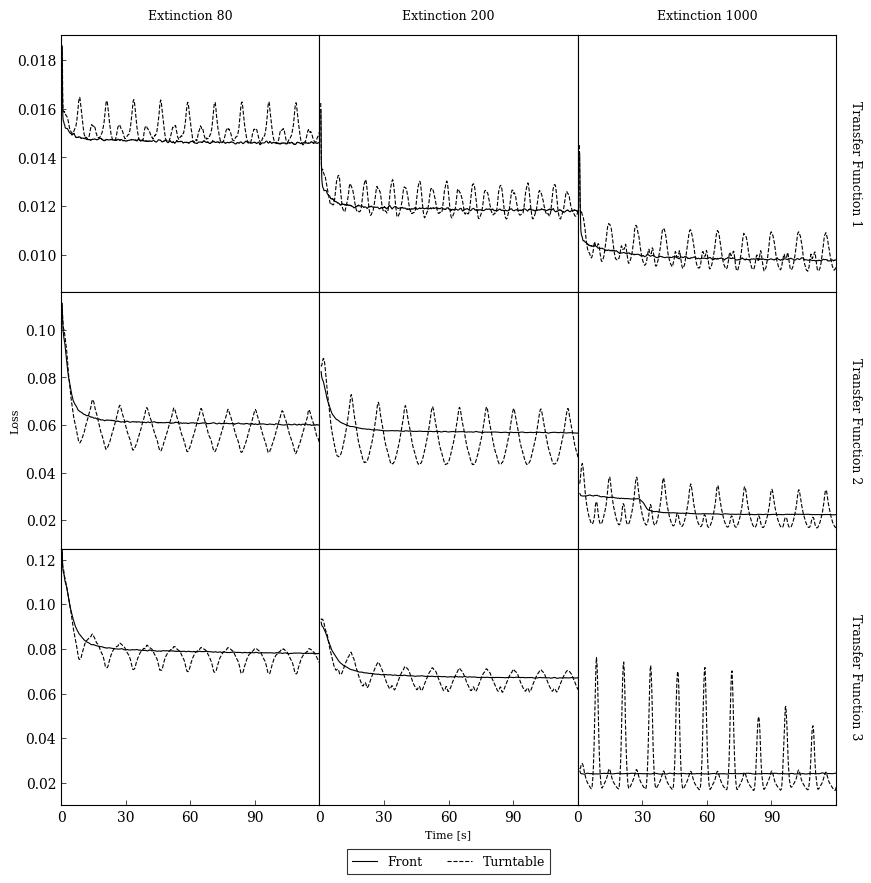

In [6]:
ylims = [(0.0085, 0.019), (0.008, 0.116), (0.01, 0.125)]
plot_loss_all('chameleon', ylims, 'online_losses_chameleon.pdf')

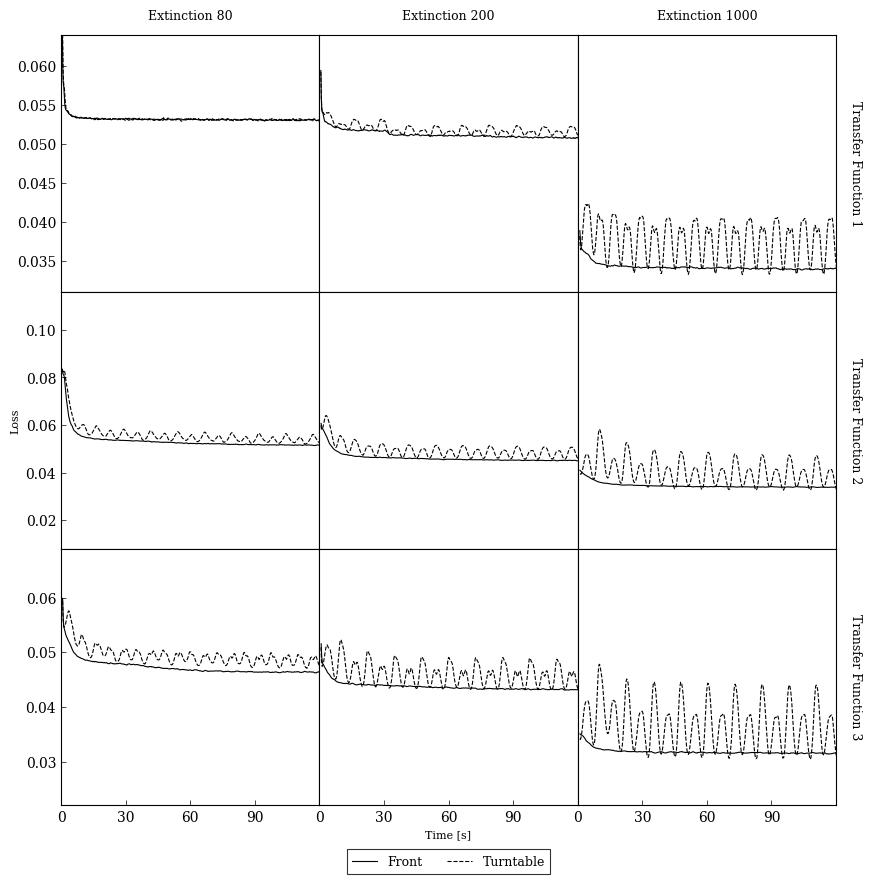

In [7]:
ylims = [(0.031, 0.064), (0.008, 0.116), (0.022, 0.069)]
plot_loss_all('mri_ventricles', ylims, 'online_losses_mri_ventricles.pdf')